Step 1: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

Step 2: Load MNIST Dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


Step 3: Visualize Dataset

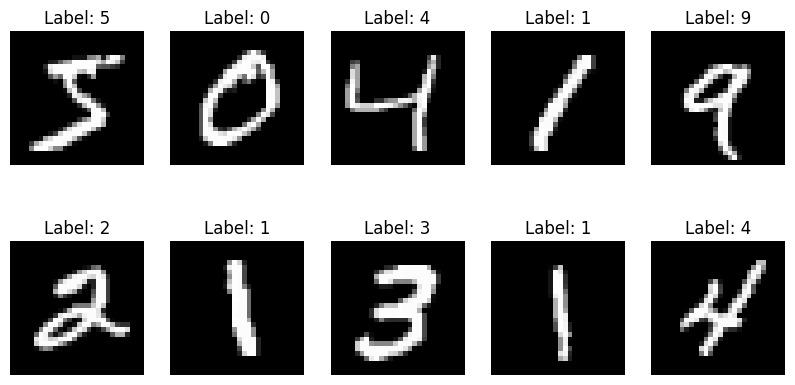

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

Step 4: Data Preprocessing

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Check pixel range:

In [ ]:
print("Maximum Value:", X_train.max())
print("Minimum Value:", X_train.min())

Maximum Value: 1.0
Minimum Value: 0.0


Step 5: One-Hot Encoding Labels

In [ ]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(y_train_cat[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


Step 6: Build Deep Learning Model
Architecture :                                                                 

Input Layer
,
Flatten
,
Dense (128)
,
Dropout
,
Dense (64)
↓
Dense (10)

In [ ]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Step 7: Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Step 8: Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Step 9: Train the Model

In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9046 - loss: 0.3165 - val_accuracy: 0.9595 - val_loss: 0.1409
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9541 - loss: 0.1487 - val_accuracy: 0.9688 - val_loss: 0.1111
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9643 - loss: 0.1117 - val_accuracy: 0.9702 - val_loss: 0.1014
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9702 - loss: 0.0931 - val_accuracy: 0.9707 - val_loss: 0.0946
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9742 - loss: 0.0802 - val_accuracy: 0.9737 - val_loss: 0.0873
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9774 - loss: 0.0708 - val_accuracy: 0.9753 - val_loss: 0.0871
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9793 - loss: 0.0641 - val_accuracy: 0.9750 - val_loss: 0.0877
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9819 - loss: 0.0559 

Step 10: Plot Accuracy Graph

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Step 11: Plot Loss Graph

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Step 12: Evaluate Model

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Step 13: Make Predictions

In [ ]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print(predicted_labels[:10])

In [ ]:
import cv2

In [ ]:
import cv2
import numpy as np

# 1. Load the image from your PC (0 forces it to load as grayscale)
image_path = '/content/74993823-8727c680-544c-11ea-96d4-c656e70c54b3.jpg'  # Update this to your file's path
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 2. Resize to 28x28 pixels (assuming MNIST dataset standards)
img_resized = cv2.resize(img, (28, 28))

# 3. CRITICAL STEP: Match the background/foreground colors
# MNIST has white digits on a black background. If your image is black ink on white paper,
# you must invert it so the model understands it.
# If your image is already white-on-black, comment out the line below.
img_inverted = cv2.bitwise_not(img_resized)

# 4. Normalize pixel values to 0.0 - 1.0 (matching your training scale)
img_normalized = img_inverted / 255.0

# 5. Reshape to add the batch dimension
# Conv2D models usually expect: (batch_size, height, width, channels) -> (1, 28, 28, 1)
# Dense/MLP models usually expect: (batch_size, features) -> (1, 784)
img_input = np.expand_dims(img_normalized, axis=(0, -1))

# 6. Make the prediction
prediction = model.predict(img_input)
predicted_label = np.argmax(prediction, axis=1)

print(f"Predicted Digit: {predicted_label[0]}")

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

Step 14: Compare Predictions

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2, 5, i+1)  # 2 rows, 5 columns
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Aactuall:{y_test[i]}\nPredicted:{predicted_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 15: Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Step 16: Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        predicted_labels
    )
)

Step 17: Predict a Single Image

In [ ]:
index = 25

image = X_test[index]

plt.imshow(image, cmap='gray')
plt.show()

prediction = model.predict(
    image.reshape(1,28,28)
)

digit = np.argmax(prediction)

print("Predicted Digit:", digit)
print("Actual Digit:", y_test[index])

Step 18: Save Model

In [ ]:
model.save("mnist_model.h5")

print("Model Saved Successfully")

Step 19: Load Saved Model

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_model.h5")

print("Model Loaded Successfully")

Step 20: Test Loaded Model

In [ ]:
prediction = loaded_model.predict(
    X_test[0].reshape(1,28,28)
)

digit = np.argmax(prediction)

print("Predicted:", digit)
print("Actual:", y_test[0])